### Vincent Barone

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,  mean_squared_error

In [4]:
df = pd.read_csv('rookies + everyone(2).csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 43 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Season           207 non-null    int64  
 1   Name             207 non-null    object 
 2   Team             207 non-null    object 
 3   Position         207 non-null    object 
 4   G                207 non-null    int64  
 5   PA               207 non-null    int64  
 6   HR               207 non-null    int64  
 7   R                207 non-null    int64  
 8   RBI              207 non-null    int64  
 9   SB               207 non-null    int64  
 10  BB%              207 non-null    float64
 11  K%               207 non-null    float64
 12  ISO              207 non-null    float64
 13  BABIP            207 non-null    float64
 14  AVG              207 non-null    float64
 15  OBP              207 non-null    float64
 16  SLG              207 non-null    float64
 17  wOBA            

In [6]:
df

,Season,Name,Team,Position,G,PA,HR,R,RBI,SB,...,Contact% (pi),Zone% (pi),Pace (pi),NameASCII,PlayerId,MLBAMID,Rookies,Rookie War,Lag_1_War,Lag_2_War
0,2022,Adley Rutschman,BAL,C,113,470,13,70,42,4,...,0.843980,0.472374,23.572368,Adley Rutschman,26288,668939,Yes,NaN,NaN,NaN
1,2023,Adley Rutschman,BAL,C,154,687,20,84,80,1,...,0.862185,0.491047,18.752703,Adley Rutschman,26288,668939,No,NaN,NaN,NaN
2,2024,Adley Rutschman,BAL,C,148,638,19,68,79,1,...,0.843018,0.505206,18.918974,Adley Rutschman,26288,668939,No,5.601840,5.509993,5.601840
3,2023,Adolis García,TEX,OF,148,632,39,108,107,9,...,0.702008,0.466797,18.809549,Adolis Garcia,19287,666969,No,NaN,NaN,NaN
4,2022,Adolis García,TEX,OF,156,657,27,88,101,25,...,0.686115,0.472167,22.560516,Adolis Garcia,19287,666969,No,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,2024,Tyrone Taylor,NYM,OF,130,345,7,47,35,11,...,0.791730,0.528744,19.328173,Tyrone Taylor,13675,621438,No,1.320360,1.030834,2.074352
203,2021,Tyrone Taylor,MIL,OF,93,271,12,33,43,6,...,0.785300,0.455323,24.199219,Tyrone Taylor,20970,660757,Yes,NaN,NaN,NaN
204,2024,Vinnie Pasquantino,KCR,1B,131,554,19,64,97,1,...,0.873892,0.498593,19.167939,Vinnie Pasquantino,27676,686469,No,1.427412,0.128035,1.427412
205,2023,Vinnie Pasquantino,KCR,1B,61,260,9,24,26,0,...,0.838641,0.479763,18.428762,Vinnie Pasquantino,27676,686469,No,NaN,NaN,NaN


In [7]:
df['Season'] = df['Season'].apply(pd.to_datetime, format='%Y')


In [8]:
df = df[df['Season'].dt.year == 2024]

In [9]:
df.head()

,Season,Name,Team,Position,G,PA,HR,R,RBI,SB,...,Contact% (pi),Zone% (pi),Pace (pi),NameASCII,PlayerId,MLBAMID,Rookies,Rookie War,Lag_1_War,Lag_2_War
2,2024-01-01,Adley Rutschman,BAL,C,148,638,19,68,79,1,...,0.843018,0.505206,18.918974,Adley Rutschman,26288,668939,No,5.601840,5.509993,5.601840
6,2024-01-01,Adolis García,TEX,OF,154,637,25,68,85,11,...,0.676270,0.471981,17.685880,Adolis Garcia,24782,681584,No,2.758908,4.651628,3.197105
10,2024-01-01,Akil Baddoo,DET,OF,31,82,2,7,5,1,...,0.693333,0.544025,17.880342,Akil Baddoo,24782,681584,No,1.721221,0.683140,-0.273945
12,2024-01-01,Alejandro Kirk,TOR,C,103,386,5,23,54,0,...,0.863506,0.497659,18.941976,Alejandro Kirk,22581,672386,No,0.738462,4.280513,2.263432
17,2024-01-01,Alek Thomas,ARI,OF,39,103,3,13,17,4,...,0.752747,0.548387,18.315789,Alek Thomas,16930,641680,No,0.780021,0.296737,0.780021


In [10]:
df_name = df['Name'].to_dict

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Season,56,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,NaN
G,56.0,113.875,11.0,94.75,123.5,144.5,161.0,36.64377
PA,56.0,418.035714,37.0,280.75,438.5,580.25,709.0,183.376608
HR,56.0,12.410714,0.0,5.0,13.0,19.0,32.0,7.724287
R,56.0,48.339286,3.0,29.0,48.0,68.0,125.0,25.168
RBI,56.0,48.410714,2.0,30.5,48.5,64.5,109.0,23.654157
SB,56.0,8.464286,0.0,1.75,5.0,11.25,40.0,9.222432
BB%,56.0,0.072127,0.027027,0.056872,0.069007,0.087238,0.125589,0.022477
K%,56.0,0.224654,0.094444,0.179735,0.227627,0.262383,0.405797,0.067269
ISO,56.0,0.150676,0.027397,0.11681,0.152145,0.179257,0.277372,0.050029


In [12]:
df_pca = df.drop(columns=[
    'WAR',
    'Season',
    'Name',
    'Position',
    'Team',
    'NameASCII',
    'Rookies'
])

In [13]:
df_pca.head(1)

,G,PA,HR,R,RBI,SB,BB%,K%,ISO,BABIP,...,O-Contact% (pi),Z-Contact% (pi),Contact% (pi),Zone% (pi),Pace (pi),PlayerId,MLBAMID,Rookie War,Lag_1_War,Lag_2_War
2,148,638,19,68,79,1,0.090909,0.161442,0.140105,0.27193,...,0.73385,0.898172,0.843018,0.505206,18.918974,26288,668939,5.60184,5.509993,5.60184


In [14]:
df_pca_st = StandardScaler().fit_transform(df_pca)

In [15]:
df_pca_st=pd.DataFrame(data=df_pca_st, columns=df_pca.columns)

In [16]:
df_pca_st.head()

,G,PA,HR,R,RBI,SB,BB%,K%,ISO,BABIP,...,O-Contact% (pi),Z-Contact% (pi),Contact% (pi),Zone% (pi),Pace (pi),PlayerId,MLBAMID,Rookie War,Lag_1_War,Lag_2_War
0,0.939691,1.210378,0.860781,0.788249,1.304892,-0.816687,0.843153,-0.948200,-0.213202,-0.415008,...,1.631641,0.798097,1.145273,-0.208014,0.791676,1.558868,0.503032,3.022148,2.168791,2.966214
1,1.104912,1.204875,1.644581,0.788249,1.560843,0.277439,-0.066597,0.798174,0.507988,-0.378597,...,-0.817436,-1.293010,-1.354589,-1.633235,-1.579177,1.139962,1.079448,0.879388,1.689083,1.155160
2,-2.282107,-1.849073,-1.359987,-1.657398,-1.851834,-0.816687,1.141767,1.569236,0.276476,-2.688816,...,-1.695949,-0.684550,-1.098777,1.457147,-1.205289,1.139962,1.079448,0.097268,-0.528758,-1.458958
3,-0.299462,-0.176280,-0.968087,-1.015917,0.238430,-0.926099,0.832580,-1.387972,-0.903446,-0.305832,...,1.651291,1.168360,1.452418,-0.531768,0.835902,0.527736,0.660162,-0.643451,1.481680,0.451992
4,-2.061813,-1.733519,-1.229354,-1.416843,-1.339933,-0.488449,-0.187018,-0.894101,0.357908,-2.152141,...,-0.388973,-0.129096,-0.208054,1.644256,-0.368059,-1.044136,-0.739557,-0.612128,-0.744704,-0.665195


In [17]:
pca = PCA(random_state=42)

In [18]:
df_pca_st=df_pca_st.dropna()

In [19]:
df_pca = pca.fit_transform(df_pca_st)

In [20]:
import numpy as np
np.set_printoptions(suppress=True, precision=10)


pca.explained_variance_

array([11.8166413741,  5.036667432 ,  3.984258294 ,  3.5245514381,
        2.5103837118,  1.63669907  ,  1.6216904478,  1.1108861681,
        1.0674195683,  0.9334286867,  0.7414311423,  0.4818076806,
        0.4030690117,  0.3091387387,  0.2559273842,  0.2170864269,
        0.2007288589,  0.1773250776,  0.1598458591,  0.1283633353,
        0.0912482311,  0.0806622827,  0.0649134915,  0.0380226323,
        0.0228203953,  0.0160401583,  0.0116487661,  0.0068225153,
        0.0040091732,  0.0006168281,  0.0002692278,  0.0001220465,
        0.          ,  0.          ,  0.          ,  0.          ])

In [21]:
pca8 = PCA(n_components=8, random_state=42)

In [22]:
df_pca8 = pca8.fit_transform(df_pca_st)

In [23]:
pca8.explained_variance_ratio_

array([0.3223786089, 0.1374090817, 0.1086975229, 0.0961559172,
       0.0684876509, 0.0446520084, 0.0442425469, 0.0303069143])

In [24]:
sum(pca8.explained_variance_ratio_)

0.8523302512256956

In [25]:
df_pca8 = pd.DataFrame(data=df_pca8, columns=['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8'])

In [26]:
df=pd.merge(df,df_pca8, how='left', left_index=True,right_index=True)

In [27]:
df.head(1)

,Season,Name,Team,Position,G,PA,HR,R,RBI,SB,...,Lag_1_War,Lag_2_War,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
2,2024-01-01,Adley Rutschman,BAL,C,148,638,19,68,79,1,...,5.509993,5.60184,-6.018766,0.158184,3.184027,1.612348,3.678264,-1.399638,-1.683464,1.147182


In [28]:
df_pca_components=pd.DataFrame(data=pca8.components_.T, columns=['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8'], index=df_pca_st.columns)

In [29]:
df_pca_components.sort_values('PC1', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
wRC+,0.263811,0.131367,0.050511,-0.112153,-0.083195,0.017662,-0.056386,-0.097921
wOBA,0.261047,0.131126,0.070018,-0.126417,-0.090765,-0.014081,-0.026977,-0.077137
OBP,0.258580,-0.009140,0.053147,-0.111988,-0.116677,0.110641,0.164324,-0.035093
R,0.255508,-0.026753,-0.089804,0.175276,0.018855,-0.025879,0.102919,0.024774
Bat,0.248497,0.083684,0.029194,-0.118129,0.002003,-0.030884,-0.045260,-0.090395


In [30]:
df_pca_components.sort_values('PC2', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
K%,-0.082992,0.360918,-0.013845,0.070726,0.227107,0.075938,-0.052903,0.063698
ISO,0.144568,0.277419,0.144621,-0.000477,0.051407,-0.232758,-0.262323,-0.155852
SLG,0.222509,0.209182,0.060891,-0.125453,-0.056834,-0.120995,-0.173724,-0.075481
BABIP2,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003
BABIP,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003


In [31]:
df_pca_components.sort_values('PC3', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Zone% (pi),-0.032561,-0.074085,0.289563,-0.106489,0.182960,0.112558,-0.002147,0.026652
BB%,0.114005,-0.002773,0.273638,0.174202,0.130314,0.023171,0.169411,-0.130977
ISO,0.144568,0.277419,0.144621,-0.000477,0.051407,-0.232758,-0.262323,-0.155852
Contact% (pi),0.083510,-0.366600,0.131372,-0.111413,-0.199676,-0.013294,0.075709,-0.040334
Z-Contact% (pi),0.068033,-0.332425,0.093308,-0.123318,-0.222942,-0.103039,0.061228,-0.054430


In [32]:
df_pca_components.sort_values('PC4', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
PA,0.216491,-0.067257,-0.113792,0.279279,-0.037005,0.001334,0.084433,0.064714
HR,0.215411,0.097265,-0.072053,0.279181,-0.013784,-0.139543,-0.090378,-0.010771
G,0.181799,-0.068353,-0.158038,0.266927,-0.061523,-0.046238,0.179469,-0.000685
RBI,0.231099,-0.018106,-0.097163,0.230252,-0.093686,-0.164345,-0.048274,0.017613
Lag_1_War,0.128695,-0.164889,-0.121307,0.197892,0.207920,0.122885,-0.130306,-0.161698


In [33]:
df_pca_components.sort_values('PC5', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Def,0.054479,-0.189480,-0.128548,-0.269441,0.360007,-0.162621,-0.108116,-0.072135
Def3,0.054479,-0.189480,-0.128548,-0.269441,0.360007,-0.162621,-0.108116,-0.072135
BsR,0.068307,0.042155,-0.098658,-0.000528,0.314942,-0.159508,0.506802,0.006503
Fld,0.082610,-0.167622,-0.133693,-0.252498,0.300626,-0.095833,-0.114141,0.102210
SB,0.147074,-0.005615,-0.168827,0.091682,0.253808,-0.012733,0.418320,-0.047034


In [34]:
df_pca_components.sort_values('PC6', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Rookie War,0.107716,-0.111824,-0.067284,0.137500,0.141187,0.496195,-0.223633,-0.178253
Lag_2_War,0.105504,-0.141791,-0.188950,0.087838,0.087923,0.444663,-0.207421,-0.253839
BABIP,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003
BABIP2,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003
Lag_1_War,0.128695,-0.164889,-0.121307,0.197892,0.207920,0.122885,-0.130306,-0.161698


In [35]:
df_pca_components.sort_values('PC7', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
BsR,0.068307,0.042155,-0.098658,-0.000528,0.314942,-0.159508,0.506802,0.006503
SB,0.147074,-0.005615,-0.168827,0.091682,0.253808,-0.012733,0.418320,-0.047034
G,0.181799,-0.068353,-0.158038,0.266927,-0.061523,-0.046238,0.179469,-0.000685
BB%,0.114005,-0.002773,0.273638,0.174202,0.130314,0.023171,0.169411,-0.130977
OBP,0.258580,-0.009140,0.053147,-0.111988,-0.116677,0.110641,0.164324,-0.035093


In [36]:
df_pca_components.sort_values('PC8', ascending=False).head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
MLBAMID,0.148503,-0.176378,0.043657,0.149697,0.043138,-0.166036,-0.187222,0.465651
PlayerId,0.179977,-0.128640,0.029314,0.117037,0.030341,-0.055805,-0.251287,0.418627
BABIP2,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003
BABIP,0.158554,0.171055,-0.141693,-0.263068,-0.074960,0.252280,0.123168,0.208003
Fld,0.082610,-0.167622,-0.133693,-0.252498,0.300626,-0.095833,-0.114141,0.102210


In [37]:
df=df.drop(columns=['NameASCII','PlayerId','MLBAMID'])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Season           56 non-null     datetime64[ns]
 1   Name             56 non-null     object        
 2   Team             56 non-null     object        
 3   Position         56 non-null     object        
 4   G                56 non-null     int64         
 5   PA               56 non-null     int64         
 6   HR               56 non-null     int64         
 7   R                56 non-null     int64         
 8   RBI              56 non-null     int64         
 9   SB               56 non-null     int64         
 10  BB%              56 non-null     float64       
 11  K%               56 non-null     float64       
 12  ISO              56 non-null     float64       
 13  BABIP            56 non-null     float64       
 14  AVG              56 non-null     float64       


In [39]:
MLB = df

In [40]:
MLB.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Season           56 non-null     datetime64[ns]
 1   Name             56 non-null     object        
 2   Team             56 non-null     object        
 3   Position         56 non-null     object        
 4   G                56 non-null     int64         
 5   PA               56 non-null     int64         
 6   HR               56 non-null     int64         
 7   R                56 non-null     int64         
 8   RBI              56 non-null     int64         
 9   SB               56 non-null     int64         
 10  BB%              56 non-null     float64       
 11  K%               56 non-null     float64       
 12  ISO              56 non-null     float64       
 13  BABIP            56 non-null     float64       
 14  AVG              56 non-null     float64       


In [41]:
MLB_Corr=MLB.select_dtypes('number').corr()

In [42]:
MLB_Corr['WAR'].sort_values(ascending=False)

WAR                1.000000
Off                0.879376
Bat                0.855923
R                  0.782107
wRC+               0.754120
OBP                0.743758
wOBA               0.736780
AVG                0.679866
xwOBA              0.678042
RBI                0.639928
SLG                0.625084
PA                 0.590883
HR                 0.589343
SB                 0.559853
Fld                0.525381
Def3               0.516989
Def                0.516989
G                  0.510831
BABIP2             0.479703
BABIP              0.479703
Lag_1_War          0.457180
PC4                0.401085
BsR                0.396382
ISO                0.380231
Lag_2_War          0.332335
Rookie War         0.325447
PC5                0.281888
BB%                0.280978
O-Contact% (pi)    0.263714
Contact% (pi)      0.242250
Z-Contact% (pi)    0.215877
PC8                0.108185
Pace (pi)          0.026468
PC7                0.015212
PC3                0.008671
PC2               -0

In [43]:
MLB.select_dtypes('number').info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 43 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   G                56 non-null     int64  
 1   PA               56 non-null     int64  
 2   HR               56 non-null     int64  
 3   R                56 non-null     int64  
 4   RBI              56 non-null     int64  
 5   SB               56 non-null     int64  
 6   BB%              56 non-null     float64
 7   K%               56 non-null     float64
 8   ISO              56 non-null     float64
 9   BABIP            56 non-null     float64
 10  AVG              56 non-null     float64
 11  OBP              56 non-null     float64
 12  SLG              56 non-null     float64
 13  wOBA             56 non-null     float64
 14  xwOBA            56 non-null     float64
 15  wRC+             56 non-null     float64
 16  BsR              56 non-null     float64
 17  Off              56 no

In [44]:
MLB['WAR'].describe()

count    56.000000
mean      1.371526
std       1.939719
min      -1.132261
25%      -0.072090
50%       1.032510
75%       2.441737
max      10.482732
Name: WAR, dtype: float64

In [45]:
q1=MLB['WAR'].quantile(0.25)
q1

-0.0720904845

In [46]:
q3= MLB['WAR'].quantile(0.75)
q3

2.44173679825

In [47]:
iqr = q3 - q1
iqr

2.51382728275

In [48]:
bins = [-1.132,0,1.0325 , 2.441, 15]
labels = ['25th Percentile', 'Average', '75th Percentile', 'Elite']
MLB['percentile']=pd.cut(MLB['WAR'],bins=bins,labels=labels,right=True)

<Axes: xlabel='percentile', ylabel='count'>

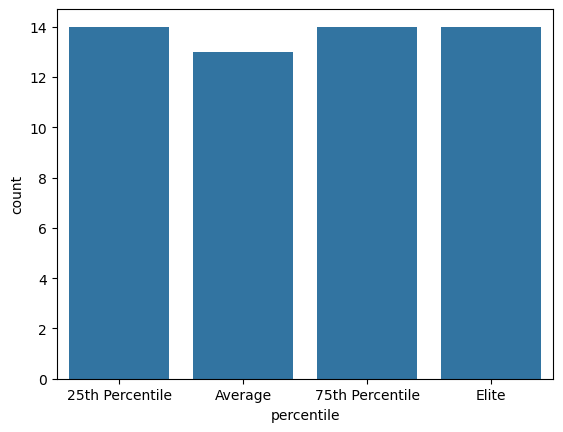

In [49]:
sns.countplot(data=MLB, x='percentile')

In [50]:
MLB['Lag_1_Diff']=MLB['WAR']-MLB['Lag_1_War']

In [51]:
MLB['Lag_2_Diff']=MLB['WAR']-MLB['Lag_2_War']

In [52]:
MLB['Rookie_Diff']=MLB['WAR']-MLB['Rookie War']

In [53]:
MLB.head()

,Season,Name,Team,Position,G,PA,HR,R,RBI,SB,...,PC3,PC4,PC5,PC6,PC7,PC8,percentile,Lag_1_Diff,Lag_2_Diff,Rookie_Diff
2,2024-01-01,Adley Rutschman,BAL,C,148,638,19,68,79,1,...,3.184027,1.612348,3.678264,-1.399638,-1.683464,1.147182,Elite,-2.795374,-2.887221,-2.887221
6,2024-01-01,Adolis García,TEX,OF,154,637,25,68,85,11,...,-2.803569,-2.307286,1.732761,-2.474538,-0.214923,-1.746834,25th Percentile,-4.803175,-3.348652,-2.910455
10,2024-01-01,Akil Baddoo,DET,OF,31,82,2,7,5,1,...,-1.823797,0.674291,1.314776,0.830757,-0.582029,0.125290,25th Percentile,-0.963945,-0.006860,-2.002026
12,2024-01-01,Alejandro Kirk,TOR,C,103,386,5,23,54,0,...,1.994005,0.322586,-0.309420,-0.086530,1.233711,-0.599978,Elite,-1.527737,0.489344,2.014314
17,2024-01-01,Alek Thomas,ARI,OF,39,103,3,13,17,4,...,0.592410,-4.742818,0.115985,1.806494,-1.011405,-0.554791,25th Percentile,-0.486982,-0.970266,-0.970266


In [54]:
MLB.to_csv('MLB_rookies_cleaned.csv') 

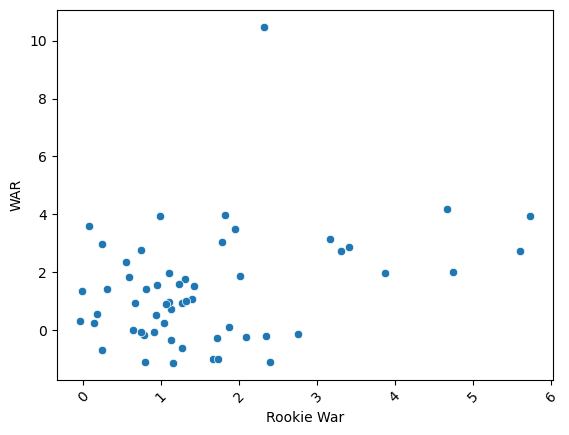

In [55]:
sns.scatterplot(data=MLB, x='Rookie War', y='WAR')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Lag_2_War', ylabel='WAR'>

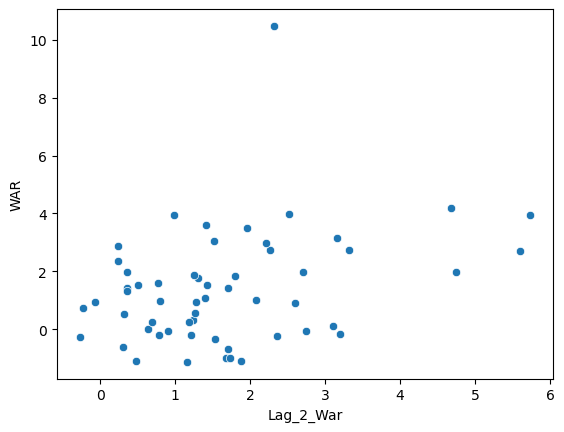

In [56]:
sns.scatterplot(data=MLB, x='Lag_2_War', y='WAR')

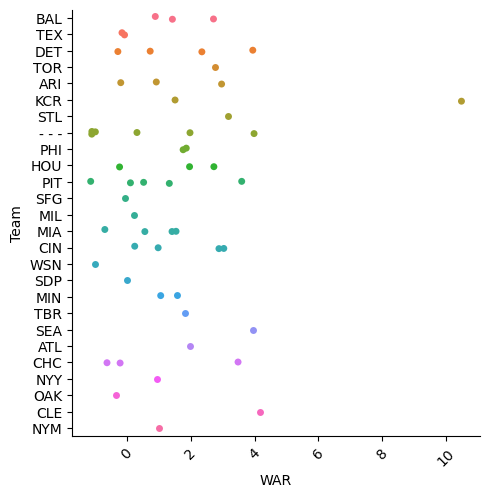

In [57]:
sns.catplot(data=MLB,  x='WAR', y='Team',hue='Team')
plt.xticks(rotation=45)
plt.show()

In [58]:
Team_SWar= MLB.groupby('Team')['WAR'].mean().sort_values(ascending=False)
top10=Team_SWar.head(10)

In [59]:
Team_RWar= MLB.groupby('Team')['Rookie War'].mean().sort_values(ascending=False)
top10_Rwar=Team_RWar.head(10)

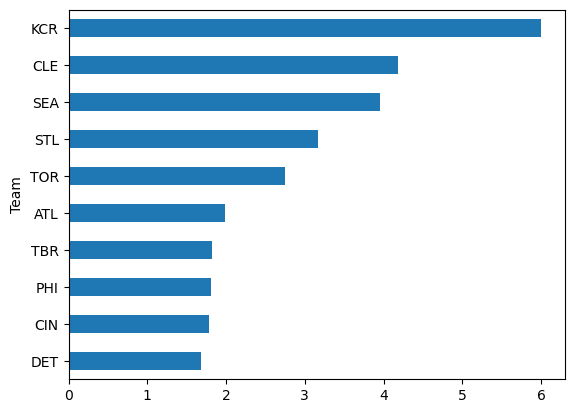

(None,)

In [60]:
top10.sort_values().plot(kind='barh')
plt.show(),


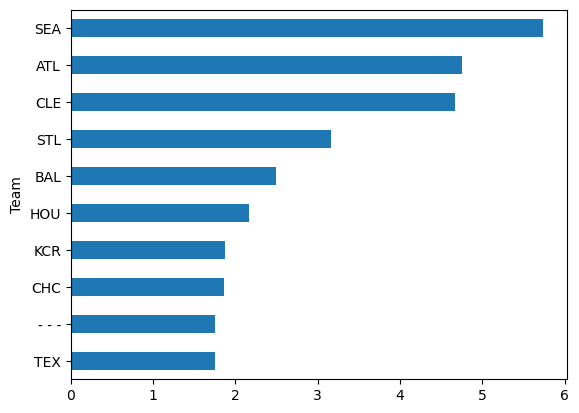

(None,)

In [61]:
top10_Rwar.sort_values().plot(kind='barh')
plt.show(),


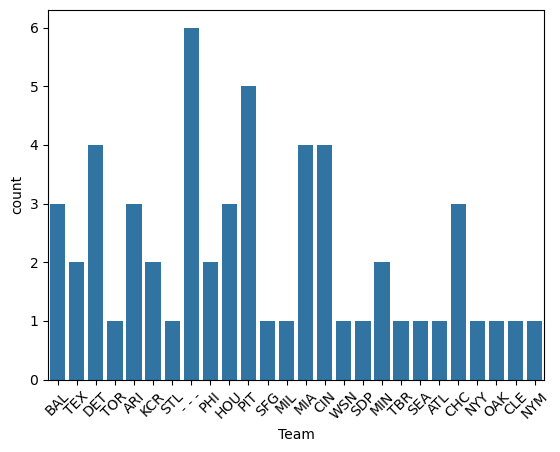

In [62]:
sns.countplot(data=MLB, x='Team')
plt.xticks(rotation=45)
plt.show()

In [63]:
MLB_Top= MLB.groupby('Name')['WAR'].sum().sort_values(ascending=False)
Ptop10=MLB_Top.head(10)

In [64]:
Rookie_Position= MLB.groupby('Position')['Rookie War'].mean()

In [65]:
Rookie_Position

Position
1B    1.205692
2B    2.039191
3B    1.206215
C     1.413284
OF    1.719207
SS    2.236906
Name: Rookie War, dtype: float64

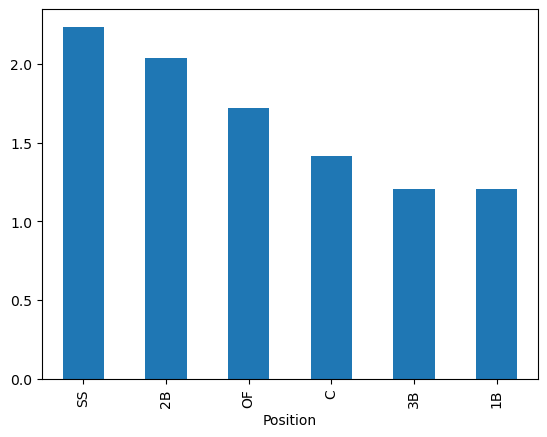

In [66]:
Rookie_Position.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [67]:
Lag_1_War_Position= MLB.groupby('Position')['Lag_1_Diff'].mean()

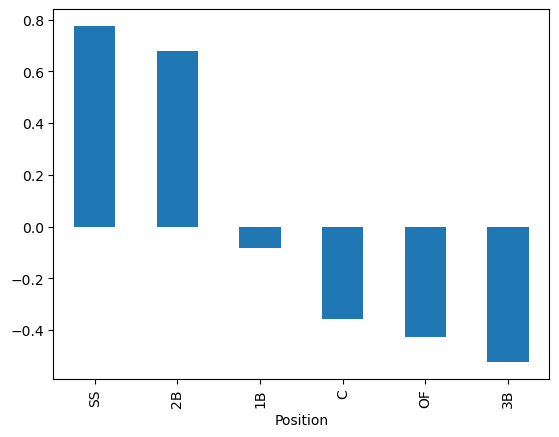

In [68]:
Lag_1_War_Position.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [69]:
Lag_2_War_Position= MLB.groupby('Position')['Lag_2_Diff'].mean()

In [70]:
Lag_2_War_Position

Position
1B   -0.918158
2B    0.807681
3B   -1.123554
C    -0.443457
OF   -0.308827
SS    2.160662
Name: Lag_2_Diff, dtype: float64

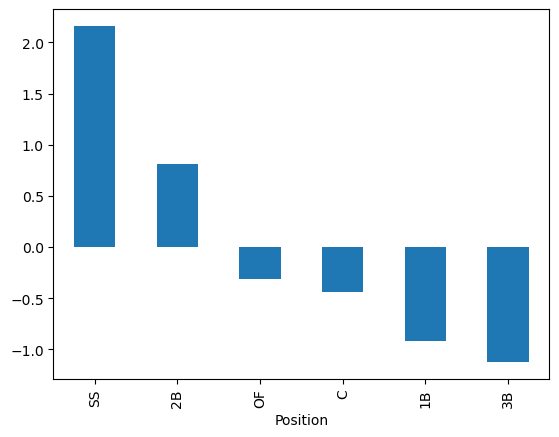

In [71]:
Lag_2_War_Position.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [72]:
Rookie_Position_Diff= MLB.groupby('Position')['Rookie_Diff'].mean()

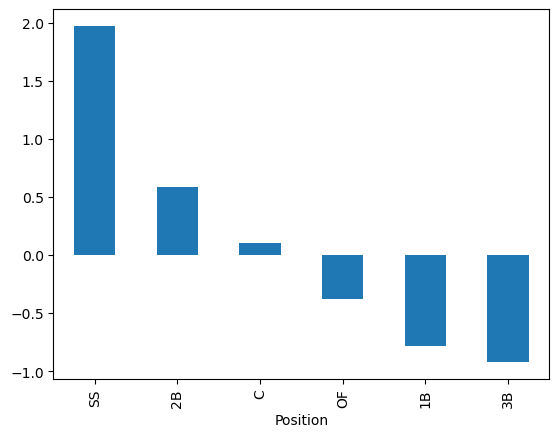

In [73]:
Rookie_Position_Diff.sort_values(ascending=False).plot(kind='bar')
plt.show()


In [74]:
Rookie_Position_Diff

Position
1B   -0.780277
2B    0.587054
3B   -0.920434
C     0.105637
OF   -0.374740
SS    1.971679
Name: Rookie_Diff, dtype: float64

<Axes: xlabel='Rookie War', ylabel='WAR'>

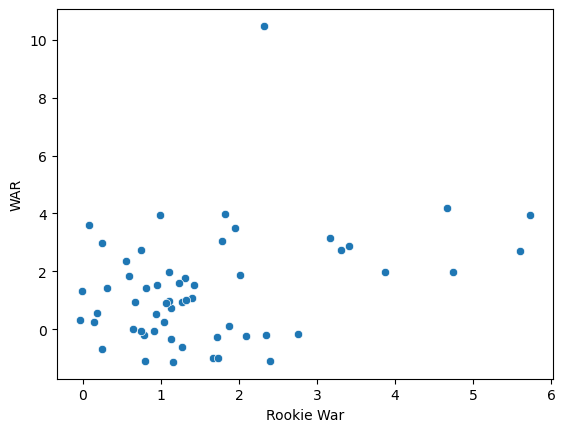

In [75]:
sns.scatterplot(data=MLB, x='Rookie War', y='WAR')

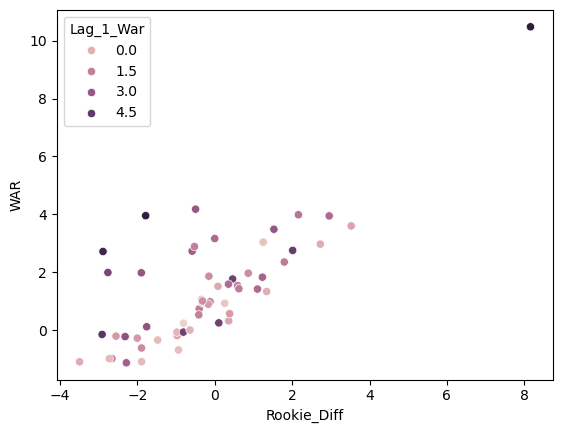

In [76]:
sns.scatterplot(data=MLB, x='Rookie_Diff', y='WAR',hue='Lag_1_War')
plt.show()

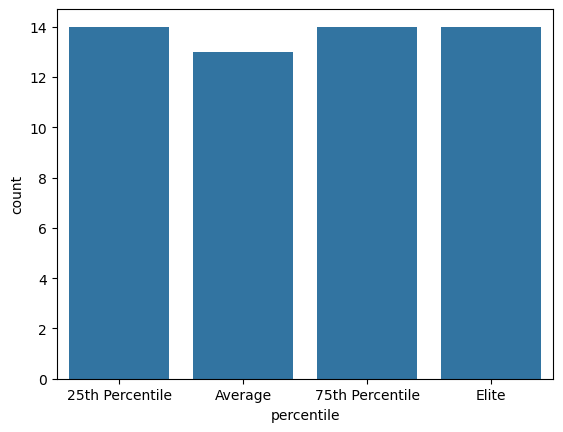

In [77]:
sns.countplot(data=MLB, x='percentile')
plt.show()

In [78]:
MLB_Corr=MLB.select_dtypes('number').corr()



In [79]:
MLB_Corr['WAR'].sort_values(ascending=False)

WAR                1.000000
Off                0.879376
Bat                0.855923
R                  0.782107
Rookie_Diff        0.765076
Lag_2_Diff         0.763603
wRC+               0.754120
OBP                0.743758
wOBA               0.736780
AVG                0.679866
xwOBA              0.678042
RBI                0.639928
SLG                0.625084
PA                 0.590883
HR                 0.589343
Lag_1_Diff         0.570093
SB                 0.559853
Fld                0.525381
Def3               0.516989
Def                0.516989
G                  0.510831
BABIP2             0.479703
BABIP              0.479703
Lag_1_War          0.457180
PC4                0.401085
BsR                0.396382
ISO                0.380231
Lag_2_War          0.332335
Rookie War         0.325447
PC5                0.281888
BB%                0.280978
O-Contact% (pi)    0.263714
Contact% (pi)      0.242250
Z-Contact% (pi)    0.215877
PC8                0.108185
Pace (pi)          0

In [80]:
MLB=MLB.drop(columns=['BsR',
                      'ISO',
                      'Lag_2_War',
                      'Rookie War',
                      'BB%',
                      'O-Contact% (pi)',
                      'Contact% (pi)',
                      'Z-Contact% (pi)',   
                      'Pace (pi)',
                      'Zone% (pi)',
                      'O-Swing% (pi)', 
                      'Z-Swing% (pi)',
                      'Swing% (pi)',
                      'K%',
                      'PC1',
                      'PC2',
                      'PC3',
                      'PC4', 
                      'PC5',
                      'PC6',
                      'PC7',
                      'PC8',
                      'Lag_1_War',
                      'Lag_1_Diff',
                      'Lag_2_Diff',
                      'Rookie_Diff'
                      
                     ])
      
     

                      


In [81]:
MLB.head(2)

,Season,Name,Team,Position,G,PA,HR,R,RBI,SB,...,wRC+,Off,Def,Fld,WAR,BABIP2,Bat,Def3,Rookies,percentile
2,2024-01-01,Adley Rutschman,BAL,C,148,638,19,68,79,1,...,102.638503,-1.056815,6.189155,3.485680,2.714619,0.271930,1.926123,6.189155,No,Elite
6,2024-01-01,Adolis García,TEX,OF,154,637,25,68,85,11,...,93.320576,-5.577890,-17.008636,-8.738748,-0.151546,0.273438,-4.868375,-17.008636,No,25th Percentile


In [82]:
MLB.select_dtypes('number').info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       56 non-null     int64  
 1   PA      56 non-null     int64  
 2   HR      56 non-null     int64  
 3   R       56 non-null     int64  
 4   RBI     56 non-null     int64  
 5   SB      56 non-null     int64  
 6   BABIP   56 non-null     float64
 7   AVG     56 non-null     float64
 8   OBP     56 non-null     float64
 9   SLG     56 non-null     float64
 10  wOBA    56 non-null     float64
 11  xwOBA   56 non-null     float64
 12  wRC+    56 non-null     float64
 13  Off     56 non-null     float64
 14  Def     56 non-null     float64
 15  Fld     56 non-null     float64
 16  WAR     56 non-null     float64
 17  BABIP2  56 non-null     float64
 18  Bat     56 non-null     float64
 19  Def3    56 non-null     float64
dtypes: float64(14), int64(6)
memory usage: 9.2 KB


In [83]:
MLB.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Season      56 non-null     datetime64[ns]
 1   Name        56 non-null     object        
 2   Team        56 non-null     object        
 3   Position    56 non-null     object        
 4   G           56 non-null     int64         
 5   PA          56 non-null     int64         
 6   HR          56 non-null     int64         
 7   R           56 non-null     int64         
 8   RBI         56 non-null     int64         
 9   SB          56 non-null     int64         
 10  BABIP       56 non-null     float64       
 11  AVG         56 non-null     float64       
 12  OBP         56 non-null     float64       
 13  SLG         56 non-null     float64       
 14  wOBA        56 non-null     float64       
 15  xwOBA       56 non-null     float64       
 16  wRC+        56 non-null     floa

In [84]:
MLB=MLB.drop(columns=['Name','Season','percentile','Rookies'])

In [85]:
MLB.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Team      56 non-null     object 
 1   Position  56 non-null     object 
 2   G         56 non-null     int64  
 3   PA        56 non-null     int64  
 4   HR        56 non-null     int64  
 5   R         56 non-null     int64  
 6   RBI       56 non-null     int64  
 7   SB        56 non-null     int64  
 8   BABIP     56 non-null     float64
 9   AVG       56 non-null     float64
 10  OBP       56 non-null     float64
 11  SLG       56 non-null     float64
 12  wOBA      56 non-null     float64
 13  xwOBA     56 non-null     float64
 14  wRC+      56 non-null     float64
 15  Off       56 non-null     float64
 16  Def       56 non-null     float64
 17  Fld       56 non-null     float64
 18  WAR       56 non-null     float64
 19  BABIP2    56 non-null     float64
 20  Bat       56 non-null     float64
 21 

In [86]:
MLB=pd.get_dummies(MLB,drop_first=True)

In [87]:
MLB.head()

,G,PA,HR,R,RBI,SB,BABIP,AVG,OBP,SLG,...,Team_STL,Team_TBR,Team_TEX,Team_TOR,Team_WSN,Position_2B,Position_3B,Position_C,Position_OF,Position_SS
2,148,638,19,68,79,1,0.271930,0.250438,0.318182,0.390543,...,False,False,False,False,False,False,False,True,False,False
6,154,637,25,68,85,11,0.273438,0.224138,0.284144,0.400000,...,False,False,True,False,False,False,False,False,True,False
10,31,82,2,7,5,1,0.177778,0.136986,0.219512,0.301370,...,False,False,False,False,False,False,False,False,True,False
12,103,386,5,23,54,0,0.276451,0.252941,0.318653,0.358824,...,False,False,False,True,False,False,False,True,False,False
17,39,103,3,13,17,4,0.200000,0.189474,0.245098,0.357895,...,False,False,False,False,False,False,False,False,True,False


In [88]:
y=MLB['WAR']

In [89]:
X=MLB.drop(columns='WAR')

In [90]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 49 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   G            56 non-null     int64  
 1   PA           56 non-null     int64  
 2   HR           56 non-null     int64  
 3   R            56 non-null     int64  
 4   RBI          56 non-null     int64  
 5   SB           56 non-null     int64  
 6   BABIP        56 non-null     float64
 7   AVG          56 non-null     float64
 8   OBP          56 non-null     float64
 9   SLG          56 non-null     float64
 10  wOBA         56 non-null     float64
 11  xwOBA        56 non-null     float64
 12  wRC+         56 non-null     float64
 13  Off          56 non-null     float64
 14  Def          56 non-null     float64
 15  Fld          56 non-null     float64
 16  BABIP2       56 non-null     float64
 17  Bat          56 non-null     float64
 18  Def3         56 non-null     float64
 19  Team_ARI     5

In [91]:
from sklearn.preprocessing import StandardScaler

In [92]:
MLB_scaler=X.iloc[:,0:19]

In [93]:
MLB_scaler.shape

(56, 19)

In [94]:
MLB_scaled =StandardScaler().fit_transform(MLB_scaler)

In [95]:
# save it to X data frame
X.iloc[:, 0:19]=MLB_scaled

/var/folders/55/xfkhpr115tx77276k4ycp0tw0000gn/T/ipykernel_98677/3230468603.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.939691234   1.1049116707 -2.2821072825 -0.2994620416 -2.0618133669
 -0.4096089994  1.2976688469  1.0773749313  0.9672279734  0.939691234
 -0.5472926967  1.0498381918  0.2512727475 -2.8328420717 -0.4922192178
 -0.6574396545  0.278809487  -2.309644022  -0.7125131335  0.6367870999
  0.0585155713  0.7744707972  0.939691234   0.9121544945  1.1875218891
  0.9672279734 -0.9328070491 -1.0429540069  0.4715666632  1.0223014523
 -1.4560050988  0.1961992686  0.4440299237  0.8020075367 -0.4922192178
  0.8295442761 -0.1067048654 -0.1067048654 -0.5197559573 -1.7313724934
  0.8846177551 -0.1342416049 -1.0704907464 -1.4835418383 -0.38207226
  1.1049116707  0.6367870999  0.2237360081  0.278809487   0.4991034027
  0.278809487   0.2237360081 -0.7951233518  0.6643238394  0.4440299237
  0.4715666632]' has d

In [96]:
X.head(2)

,G,PA,HR,R,RBI,SB,BABIP,AVG,OBP,SLG,...,Team_STL,Team_TBR,Team_TEX,Team_TOR,Team_WSN,Position_2B,Position_3B,Position_C,Position_OF,Position_SS
2,0.939691,1.210378,0.860781,0.788249,1.304892,-0.816687,-0.415008,0.246712,0.405207,-0.037494,...,False,False,False,False,False,False,False,True,False,False
6,1.104912,1.204875,1.644581,0.788249,1.560843,0.277439,-0.378597,-0.554255,-0.597688,0.106073,...,False,False,True,False,False,False,False,False,True,False


In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(44, 49)
(12, 49)
(44,)
(12,)


In [99]:
lr=LinearRegression()

In [100]:
lr.fit(X_train,y_train)

LinearRegression()

In [101]:
pred_lr=lr.predict(X_test)

In [102]:
pred_lr

array([ 2.7336463763,  0.7294777279,  3.9437946303, -0.068077341 ,
        1.4114961614, -0.3669003978,  1.9812873179,  1.3325047248,
        0.8997952289,  0.5073166622,  0.992774763 ,  2.754452211 ])

In [103]:
mae_lr=mean_absolute_error(y_test, pred_lr)
mse_lr=mean_squared_error(y_test, pred_lr)
rmse_lr=np.sqrt(mse_lr)

In [104]:
lr_pm=pd.DataFrame({'MAE':[mae_lr], 'MSE':[mse_lr], 'RMSE':[rmse_lr]}, index=['Linear Regression'])
lr_pm

,MAE,MSE,RMSE
Linear Regression,0.008902,0.000123,0.011111


In [105]:
dtr=DecisionTreeRegressor()

In [106]:
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

In [107]:
pred_dtr=dtr.predict(X_test)

In [108]:
Knr=KNeighborsRegressor()

In [109]:
Knr.fit(X_train,y_train)

KNeighborsRegressor()

In [110]:
pred_knr=Knr.predict(X_test)

In [111]:
mae_dtr=mean_absolute_error(y_test, pred_dtr)
mse_dtr=mean_squared_error(y_test, pred_dtr)
rmse_dtr=np.sqrt(mse_dtr)

In [112]:
dtr_pm=pd.DataFrame({'MAE':[mae_dtr], 'MSE':[mse_dtr], 'RMSE':[rmse_dtr]}, index=['DecisonTree'])
dtr_pm

,MAE,MSE,RMSE
DecisonTree,0.478644,0.397642,0.630588


In [113]:
mae_Knr=mean_absolute_error(y_test, pred_knr)
mse_knr=mean_squared_error(y_test, pred_knr)
rmse_knr=np.sqrt(mse_knr)

In [114]:
knr_pm=pd.DataFrame({'MAE':[mae_Knr], 'MSE':[mse_knr], 'RMSE':[rmse_knr]}, index=['Kneighbors'])
knr_pm

,MAE,MSE,RMSE
Kneighbors,0.433797,0.351669,0.593017


In [115]:
pm=pd.concat([lr_pm,dtr_pm,knr_pm],axis=0)
pm

,MAE,MSE,RMSE
Linear Regression,0.008902,0.000123,0.011111
DecisonTree,0.478644,0.397642,0.630588
Kneighbors,0.433797,0.351669,0.593017


In [116]:
Model1_coefficient=pd.DataFrame(lr.coef_,columns=['coefficients'],index=X.columns)
Model1_coefficient.sort_values(by='coefficients',ascending=False)
Model1_coefficient['abs_coef']=Model1_coefficient['coefficients'].abs()
Model1_coefficient
Model1_top5=Model1_coefficient.sort_values(by='abs_coef',ascending=False).head()

In [117]:
Model1_top5

,coefficients,abs_coef
Off,1.310753,1.310753
PA,0.630770,0.630770
Def,0.385878,0.385878
Def3,0.385878,0.385878
wRC+,-0.050949,0.050949


In [118]:
Model1_top5_dtr=pd.DataFrame(dtr.feature_importances_,columns=['Importances'],index=X.columns).sort_values('Importances',ascending=False)

In [119]:
Model1_top5_dtr = pd.DataFrame(
    data=dtr.feature_importances_,columns=['Importances'],index=X.columns).sort_values('Importances', ascending=False)
Model1_top5_dtr=Model1_top5_dtr.head()
Model1_top5_dtr

,Importances
Off,0.502564
wRC+,0.250525
wOBA,0.112810
Def3,0.072621
SLG,0.018716


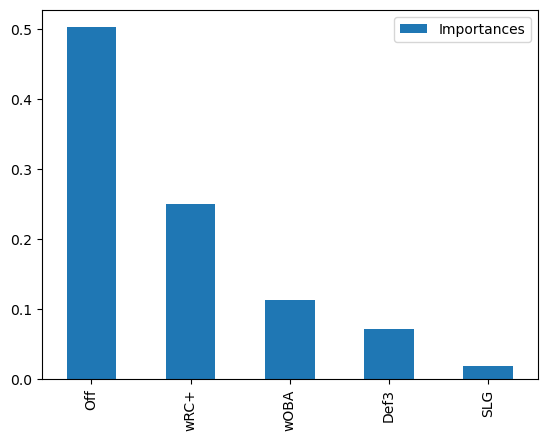

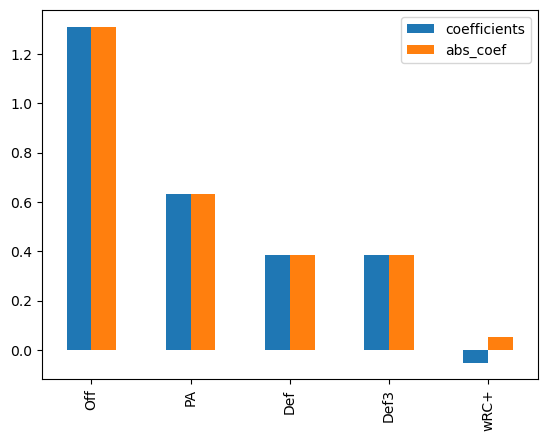

In [120]:
Model1_top5_dtr.plot(kind='bar')
plt.show()
Model1_top5.plot(kind='bar')
plt.show()

In [359]:
Prediction = pd.DataFrame({'Actual War':pred_lr, 'Predicted War':y_test})

In [361]:
Prediction

,Actual War,Predicted War
2,2.733646,2.714619
20,0.729478,0.731457
123,3.943795,3.952758
46,-0.068077,-0.072045
70,1.411496,1.415852
186,-0.366900,-0.346601
134,1.981287,1.987951
96,1.332505,1.330698
164,0.899795,0.891564
43,0.507317,0.525755


In [363]:
Prediction['Difference in Prediction'] = Prediction['Actual War'] - Prediction['Predicted War']

In [365]:
Prediction.sort_values(by= 'Difference in Prediction',ascending=False)

,Actual War,Predicted War,Difference in Prediction
2,2.733646,2.714619,0.019027
164,0.899795,0.891564,0.008232
46,-0.068077,-0.072045,0.003967
96,1.332505,1.330698,0.001807
12,2.754452,2.752776,0.001676
20,0.729478,0.731457,-0.001979
70,1.411496,1.415852,-0.004356
134,1.981287,1.987951,-0.006664
123,3.943795,3.952758,-0.008964
202,0.992775,1.004188,-0.011413


In [367]:
Prediction_Plot = Prediction[['Predicted War','Difference in Prediction']]

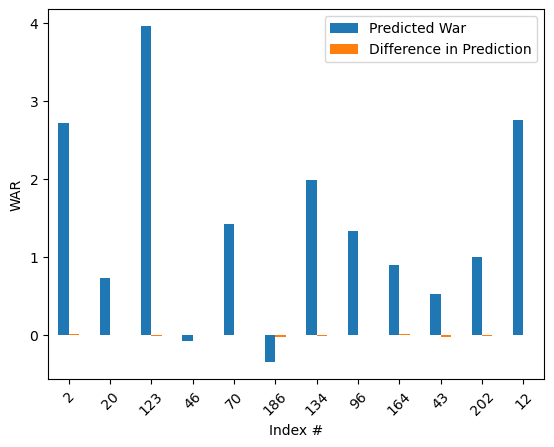

In [369]:
Prediction_Plot.plot(kind='bar')
plt.xlabel('Index #')
plt.ylabel('WAR')
plt.xticks(rotation=45)
plt.show()

In [127]:
MLB=pd.get_dummies(MLB,drop_first=True)

In [128]:
y=MLB['WAR']

In [129]:
MLB=MLB.drop(columns=['G',           
                  'PA',
                  'HR',
                  'R',
                  'RBI',
                  'SB',
                  'BABIP',
                  'AVG',
                  'OBP',
                  'SLG',
                  'wOBA',
                  'xwOBA',
                  'wRC+',
                  'Off',
                  'Def',
                  'Fld',
                  'BABIP2',
                  'Bat',
                  'Def3',
                      'WAR'])        

In [130]:
MLB.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 2 to 204
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Team_ARI     56 non-null     bool 
 1   Team_ATL     56 non-null     bool 
 2   Team_BAL     56 non-null     bool 
 3   Team_CHC     56 non-null     bool 
 4   Team_CIN     56 non-null     bool 
 5   Team_CLE     56 non-null     bool 
 6   Team_DET     56 non-null     bool 
 7   Team_HOU     56 non-null     bool 
 8   Team_KCR     56 non-null     bool 
 9   Team_MIA     56 non-null     bool 
 10  Team_MIL     56 non-null     bool 
 11  Team_MIN     56 non-null     bool 
 12  Team_NYM     56 non-null     bool 
 13  Team_NYY     56 non-null     bool 
 14  Team_OAK     56 non-null     bool 
 15  Team_PHI     56 non-null     bool 
 16  Team_PIT     56 non-null     bool 
 17  Team_SDP     56 non-null     bool 
 18  Team_SEA     56 non-null     bool 
 19  Team_SFG     56 non-null     bool 
 20  Team_STL     56 

In [131]:
X=MLB.iloc[:,0:30].reset_index()

In [132]:
X=X.drop(columns='index')

In [133]:
X.head(2)

,Team_ARI,Team_ATL,Team_BAL,Team_CHC,Team_CIN,Team_CLE,Team_DET,Team_HOU,Team_KCR,Team_MIA,...,Team_STL,Team_TBR,Team_TEX,Team_TOR,Team_WSN,Position_2B,Position_3B,Position_C,Position_OF,Position_SS
0,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [134]:
X=X.merge(df_pca8, how='left', left_index=True,right_index=True)

In [135]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 38 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Team_ARI     56 non-null     bool   
 1   Team_ATL     56 non-null     bool   
 2   Team_BAL     56 non-null     bool   
 3   Team_CHC     56 non-null     bool   
 4   Team_CIN     56 non-null     bool   
 5   Team_CLE     56 non-null     bool   
 6   Team_DET     56 non-null     bool   
 7   Team_HOU     56 non-null     bool   
 8   Team_KCR     56 non-null     bool   
 9   Team_MIA     56 non-null     bool   
 10  Team_MIL     56 non-null     bool   
 11  Team_MIN     56 non-null     bool   
 12  Team_NYM     56 non-null     bool   
 13  Team_NYY     56 non-null     bool   
 14  Team_OAK     56 non-null     bool   
 15  Team_PHI     56 non-null     bool   
 16  Team_PIT     56 non-null     bool   
 17  Team_SDP     56 non-null     bool   
 18  Team_SEA     56 non-null     bool   
 19  Team_SFG  

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [137]:
X_train.columns

Index(['Team_ARI', 'Team_ATL', 'Team_BAL', 'Team_CHC', 'Team_CIN', 'Team_CLE',
       'Team_DET', 'Team_HOU', 'Team_KCR', 'Team_MIA', 'Team_MIL', 'Team_MIN',
       'Team_NYM', 'Team_NYY', 'Team_OAK', 'Team_PHI', 'Team_PIT', 'Team_SDP',
       'Team_SEA', 'Team_SFG', 'Team_STL', 'Team_TBR', 'Team_TEX', 'Team_TOR',
       'Team_WSN', 'Position_2B', 'Position_3B', 'Position_C', 'Position_OF',
       'Position_SS', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'],
      dtype='object')

In [138]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(44, 38)
(12, 38)
(44,)
(12,)


In [139]:
lr2=LinearRegression()

In [140]:
lr2.fit(X_train,y_train)

LinearRegression()

In [141]:
pred_lr2=lr2.predict(X_test)

In [142]:
pred_lr2

array([ 3.7713965012,  0.8912890555,  4.7086167354,  0.5678249434,
        0.6616707712, -0.9675216027,  2.8779355302,  1.3637814403,
        1.115712832 , -0.2712037402,  1.6320755893,  3.4359449673])

In [143]:
mae_lr2=mean_absolute_error(y_test, pred_lr2)
mse_lr2=mean_squared_error(y_test, pred_lr2)
rmse_lr2=np.sqrt(mse_lr2)

In [144]:
lr_pm2=pd.DataFrame({'MAE':[mae_lr2], 'MSE':[mse_lr2], 'RMSE':[rmse_lr2]}, index=['Linear Regression2'])
lr_pm2

,MAE,MSE,RMSE
Linear Regression2,0.603556,0.45141,0.671871


In [145]:
dtr2=DecisionTreeRegressor()

In [146]:
dtr2.fit(X_train,y_train)

DecisionTreeRegressor()

In [147]:
pred_dtr2=dtr2.predict(X_test)

In [148]:
mae_dtr2=mean_absolute_error(y_test, pred_dtr2)
mse_dtr2=mean_squared_error(y_test, pred_dtr2)
rmse_dtr2=np.sqrt(mse_dtr2)

In [149]:
dtr_pm2=pd.DataFrame({'MAE':[mae_dtr2], 'MSE':[mse_dtr2], 'RMSE':[rmse_dtr2]}, index=['DecisonTree2'])
dtr_pm2

,MAE,MSE,RMSE
DecisonTree2,0.776891,1.05111,1.025236


In [150]:
Knr2=KNeighborsRegressor()

In [151]:
Knr2.fit(X_train,y_train)

KNeighborsRegressor()

In [152]:
pred_knr2=Knr2.predict(X_test)

In [153]:
mae_Knr2=mean_absolute_error(y_test, pred_knr2)
mse_knr2=mean_squared_error(y_test, pred_knr2)
rmse_knr2=np.sqrt(mse_knr2)

In [154]:
knr_pm2=pd.DataFrame({'MAE':[mae_Knr2], 'MSE':[mse_knr2], 'RMSE':[rmse_knr2]}, index=['Kneighbors2'])
knr_pm2

,MAE,MSE,RMSE
Kneighbors2,0.464682,0.397065,0.630131


In [155]:
pm2=pd.concat([lr_pm2,dtr_pm2,knr_pm2],axis=0)
pm2

,MAE,MSE,RMSE
Linear Regression2,0.603556,0.451410,0.671871
DecisonTree2,0.776891,1.051110,1.025236
Kneighbors2,0.464682,0.397065,0.630131


In [389]:
Model2_coefficient=pd.DataFrame(lr2.coef_,columns=['coefficients'],index=X.columns)
Model2_coefficient.sort_values(by='coefficients',ascending=False)
Model2_coefficient['abs_coef']=Model2_coefficient['coefficients'].abs()
Model2_coefficient
Model2_top5=Model2_coefficient.sort_values(by='abs_coef',ascending=False).head()

In [391]:
Model2_top5

,coefficients,abs_coef
Team_MIL,-1.625887,1.625887
Team_PHI,-1.218876,1.218876
Team_STL,1.206514,1.206514
Position_SS,0.951039,0.951039
Position_C,0.924049,0.924049


In [393]:
Model2_top5_dtr=pd.DataFrame(dtr2.feature_importances_,columns=['Importances'],index=X.columns).sort_values('Importances',ascending=False)

In [395]:
Model2_top5_dtr = pd.DataFrame(
    data=dtr2.feature_importances_,columns=['Importances'],index=X.columns).sort_values('Importances', ascending=False)
Model2_top5_dtr=Model2_top5_dtr.head()
Model2_top5_dtr

,Importances
PC1,0.611760
PC8,0.302550
PC6,0.039019
PC4,0.015475
PC2,0.012608


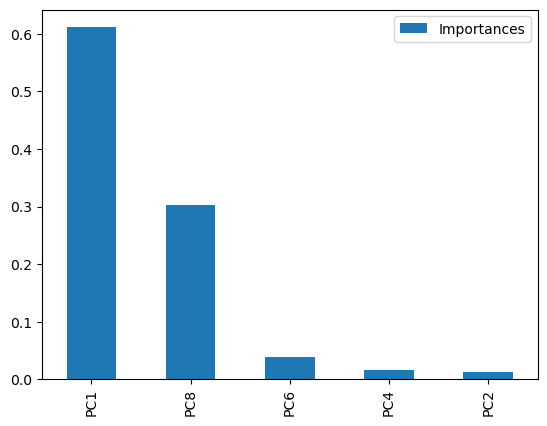

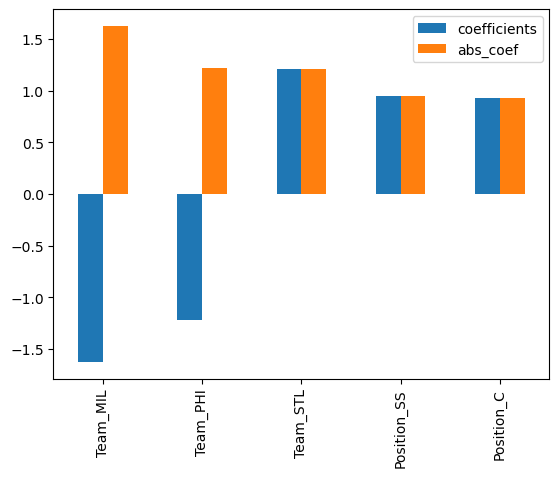

In [399]:
Model2_top5_dtr.plot(kind='bar')
plt.show()
Model2_top5.plot(kind='bar')
plt.show()

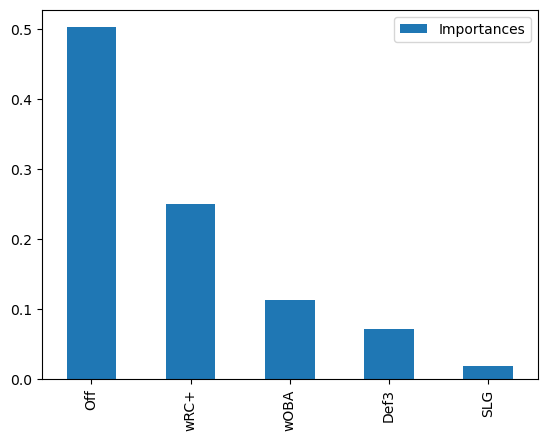

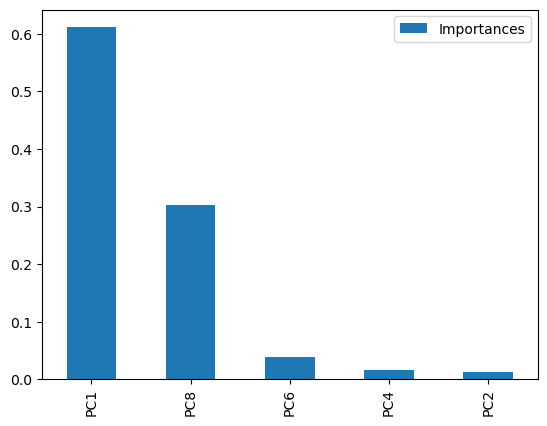

In [401]:
Model1_top5_dtr.plot(kind='bar')
plt.show()
Model2_top5_dtr.plot(kind='bar')
plt.show()

In [403]:
final_comparison=pd.concat([lr_pm,dtr_pm,knr_pm,lr_pm2,dtr_pm2,knr_pm2],axis=0)
final_comparison

,MAE,MSE,RMSE
Linear Regression,0.008902,0.000123,0.011111
DecisonTree,0.478644,0.397642,0.630588
Kneighbors,0.433797,0.351669,0.593017
Linear Regression2,0.603556,0.451410,0.671871
DecisonTree2,0.776891,1.051110,1.025236
Kneighbors2,0.464682,0.397065,0.630131


In [163]:
PC1_var=df_pca_components['PC1'].sort_values (ascending=False).head()

In [164]:
PC8_var=df_pca_components['PC8'].sort_values (ascending=False).head()

In [165]:
PC5_var=df_pca_components['PC5'].sort_values (ascending=False).head()

In [166]:
PC6_var=df_pca_components['PC6'].sort_values (ascending=False).head()

In [167]:
PC4_var=df_pca_components['PC4'].sort_values (ascending=False).head()

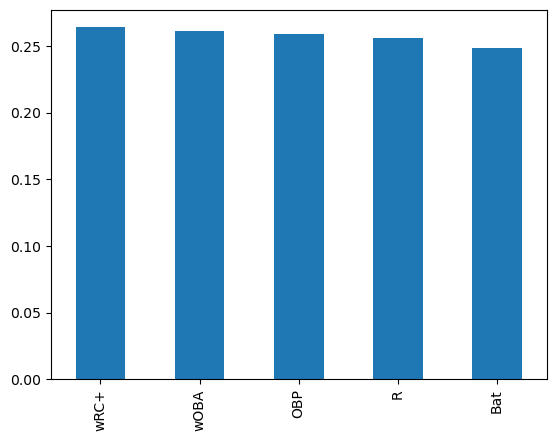

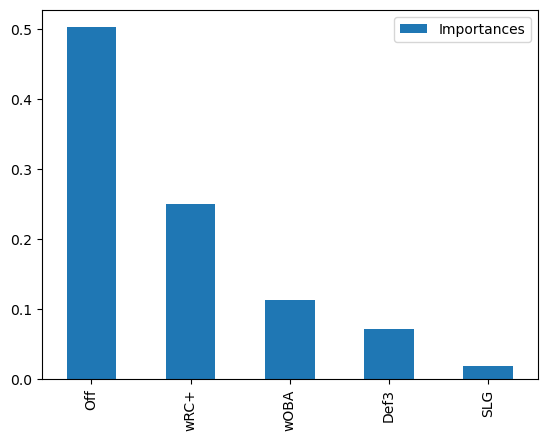

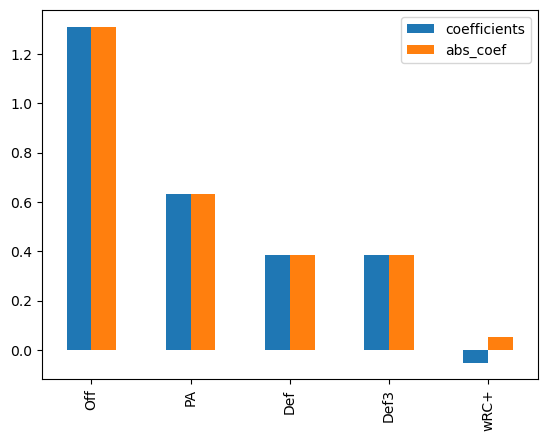

In [168]:
PC1_var.plot(kind='bar')
plt.show(),
Model1_top5_dtr.plot(kind='bar')
plt.show(),
Model1_top5.plot(kind='bar')
plt.show()

In [169]:
top_predictors=pd.concat([Model1_top5_dtr,PC1_var,Model1_top5],axis=1)

In [170]:
top_predictors  

,Importances,PC1,coefficients,abs_coef
Off,0.502564,NaN,1.310753,1.310753
wRC+,0.250525,0.263811,-0.050949,0.050949
wOBA,0.112810,0.261047,NaN,NaN
Def3,0.072621,NaN,0.385878,0.385878
SLG,0.018716,NaN,NaN,NaN
OBP,NaN,0.258580,NaN,NaN
R,NaN,0.255508,NaN,NaN
Bat,NaN,0.248497,NaN,NaN
PA,NaN,NaN,0.630770,0.630770
Def,NaN,NaN,0.385878,0.385878


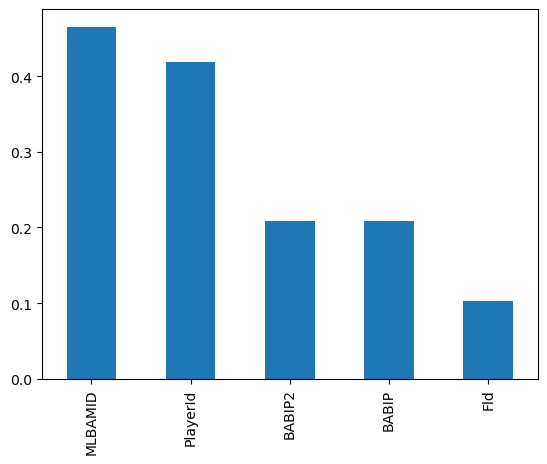

In [171]:
PC8_var.plot(kind='bar')
plt.show()


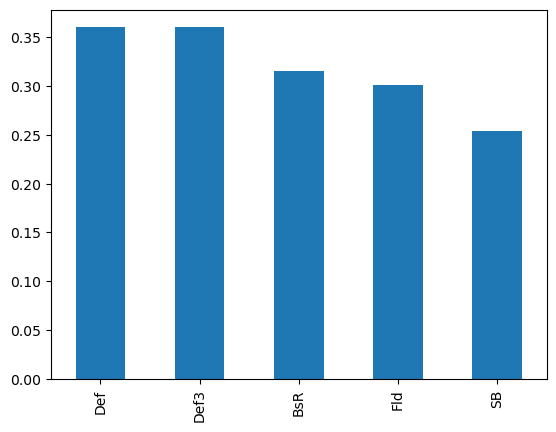

In [172]:
PC5_var.plot(kind='bar')
plt.show()

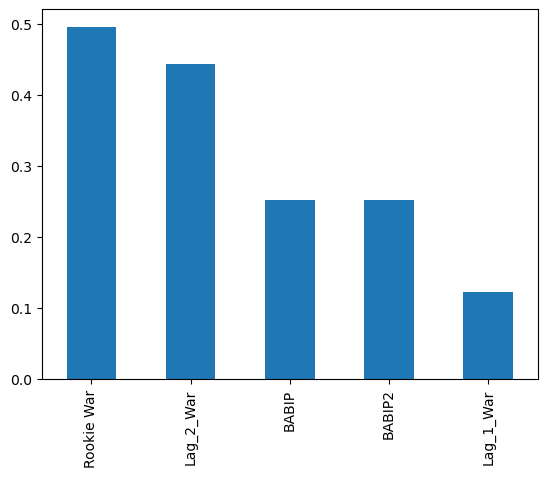

In [173]:
PC6_var.plot(kind='bar')
plt.show()

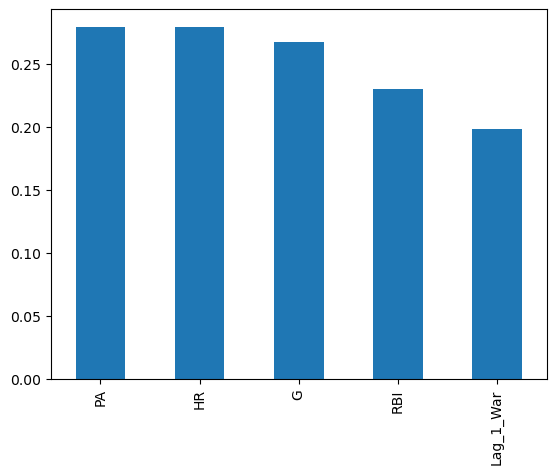

In [174]:
PC4_var.plot(kind='bar')
plt.show()

<Axes: >

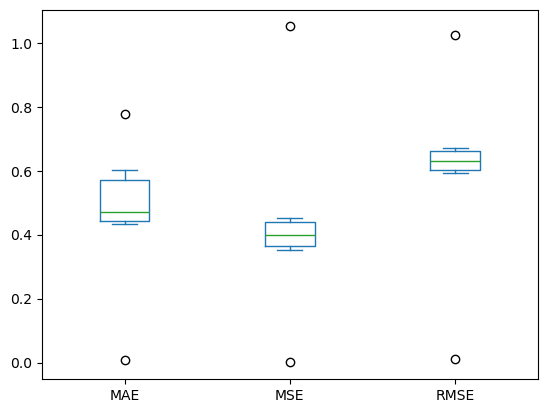

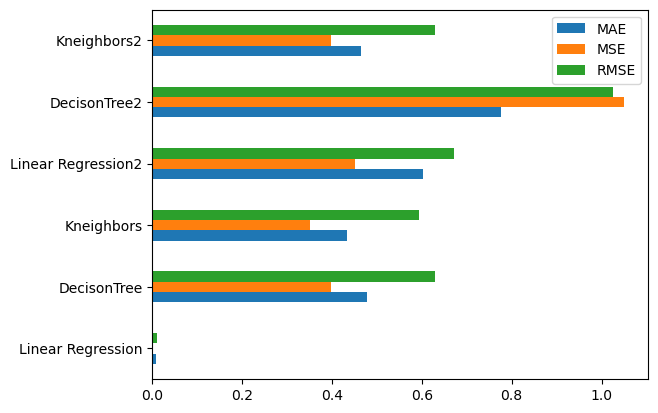

In [175]:
final_comparison.plot(kind='box')
final_comparison.plot(kind='barh')

In [176]:
Prediction = pd.DataFrame({'Actual War':pred_knr2, 'Predicted War':y_test})

In [177]:
Prediction['Difference in Prediction'] = Prediction['Actual War'] - Prediction['Predicted War']

In [178]:
Prediction.sort_values(by= 'Difference in Prediction',ascending=False)

,Actual War,Predicted War,Difference in Prediction
46,0.402942,-0.072045,0.474987
164,1.364791,0.891564,0.473228
96,1.642910,1.330698,0.312212
2,2.922973,2.714619,0.208354
202,1.107231,1.004188,0.103043
43,0.574748,0.525755,0.048994
134,2.025142,1.987951,0.037191
20,0.388288,0.731457,-0.343169
186,-0.711048,-0.346601,-0.364447
70,0.904189,1.415852,-0.511663


In [179]:
Prediction_Plot = Prediction[['Predicted War','Difference in Prediction']]

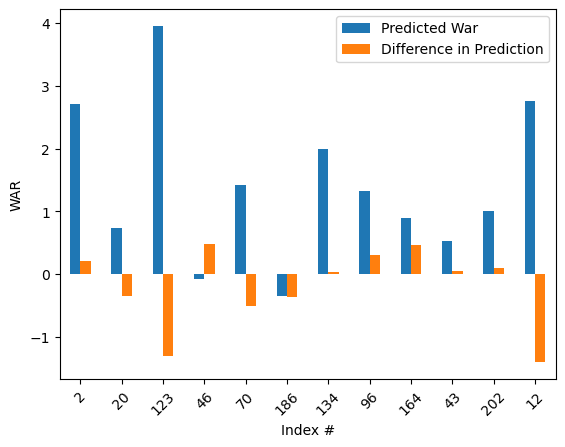

In [180]:
Prediction_Plot.plot(kind='bar')
plt.xlabel('Index #')
plt.ylabel('WAR')
plt.xticks(rotation=45)
plt.show()